# CNN Cancer Detection

## 1. The Problem and the Data
In this project I will create a deep learning model for identifying metastatic cancer in medical images. I will focus on Convolutional Neural Networks, starting from a basic architecture, then adding more layers, applying regularization techniques and fine tuning. 

The data for the project is taken from Kaggle: https://www.kaggle.com/competitions/histopathologic-cancer-detection/data. The train set consists of 220,025 images of pathological scans, and a corresponding dataset which maps each image to a binary label, indicating whether the image contains a tumor tissue or not. The test set is 57458 unlabeled images.

I will start with importing the required libraries and showing basic info of the train dataset:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from PIL import Image

df = pd.read_csv('train_labels.csv')

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220025 entries, 0 to 220024
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   id      220025 non-null  object
 1   label   220025 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.4+ MB


,id,label
0,f38a6374c348f90b587e046aac6079959adf3835,0
1,c18f2d887b7ae4f6742ee445113fa1aef383ed77,1
2,755db6279dae599ebb4d39a9123cce439965282d,0
3,bc3f0c64fb968ff4a8bd33af6971ecae77c75e08,0
4,068aba587a4950175d04c680d38943fd488d6a9d,0


From the above details, it is seen that the dataset contains 220025 rows, corresponding to the number of images, each row has an id and a label, where id is a string referring to the filename of the image.

## 2. EDA

To understand how data is distributed, I will check the histogram

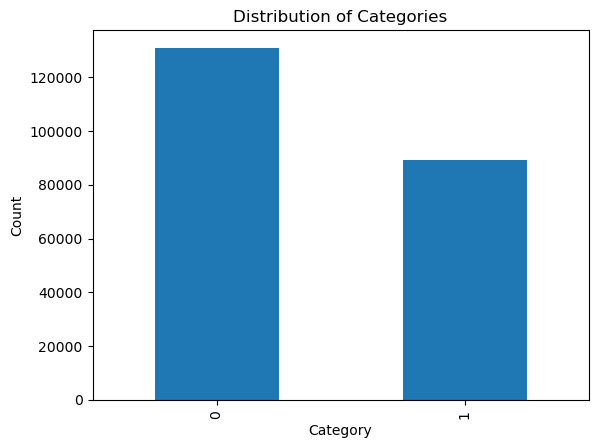

In [3]:
# create histogram of the labels
df['label'].value_counts().plot(kind='bar')
plt.title('Distribution of Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

The data is not perfectly balanced, I will need to take that into account when building the model.

Next, I will explore the images, which can provide much more insights. I will plot 30 images for each label to get a general impression of the scans:

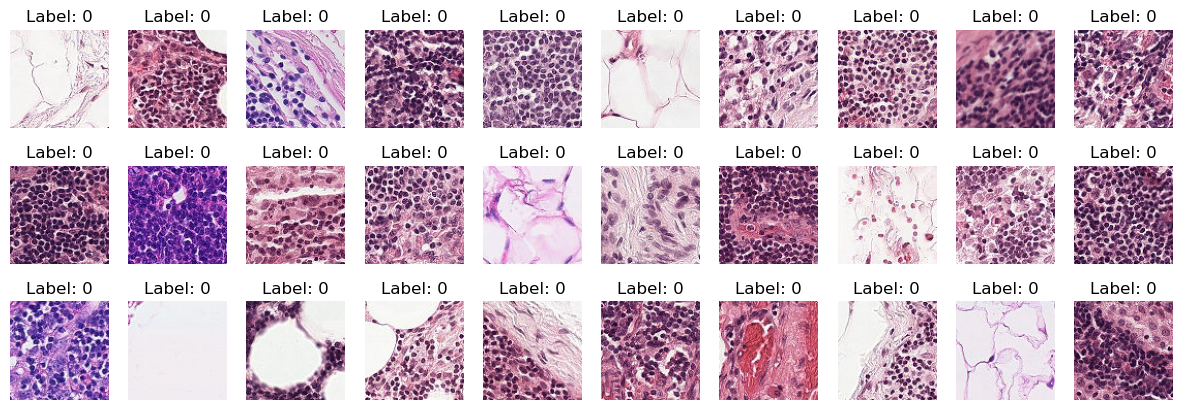

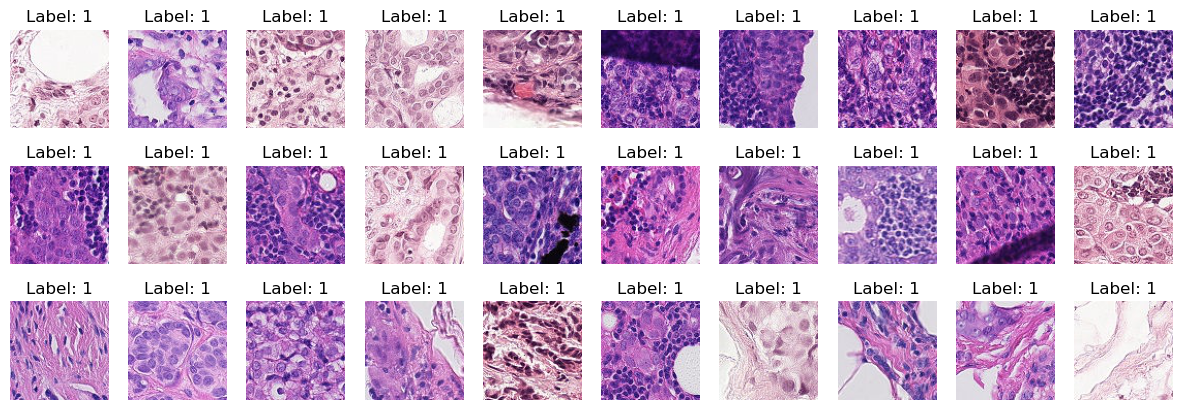

In [4]:
def show_images(df, label, n, m):
    fig, axes = plt.subplots(nrows=n, ncols=m, figsize=(15, 5))
    for i in range(n):
        for j in range(m):
            idx = np.random.choice(df[df['label'] == label].index)
            img = plt.imread(f"train/{df.loc[idx, 'id']}.tif")
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            axes[i, j].set_title(f"Label: {df.loc[idx, 'label']}")
    plt.show()

show_images(df, label=0, n=3, m=10)
show_images(df, label=1, n=3, m=10)

From the above examples I can deduct a few important points:
* The images are in rgb color, which means I will have 3 values for each pixel.
* The dark dots in the images are probably cells, and it seems that cells in images which are labeled with 1, have slightly different shape. This difference is what my algirithm will probably need to learn. But there could be other distinguishing signs that are not clearly visible.
* It's also clear that the captured objects in these images are very different from objects in other popular datasets, like ImageNet, Cifar-10, MNIST and etc. And therefore models which work good for those datasets will probably be less performant here. It seems there is no complex multilayer composition of objects (like in images of people, for example), and it could imply that I will not need too many layers in my network.

Finally, I will check a single image size:

In [5]:
img = plt.imread(f"train/{df.loc[0, 'id']}.tif")
img.shape

(96, 96, 3)

## 3. DModel Architecture
Before building the model I need to create a data generator. It will allow creating image data on the fly during model training, instead of loading all images at once. It is a necessary step when working with big dataset, otherwise the memory runs out fast. I will use the tf.data.Dataset for data generation.

However, even with data generator, I will not be able to train on all 220k images, as it will take too much time on my laptop. So I will take 10000 random samples. The code with more comments is below:

In [20]:
NUM_OF_SAMPLES = 10000

# Read the labels data
df = pd.read_csv('train_labels.csv')

# Take 5000 samples from each class
samples_1 = df[df['label'] == 0].sample(n=NUM_OF_SAMPLES // 2, random_state=42)
samples_2 = df[df['label'] == 1].sample(n=NUM_OF_SAMPLES // 2, random_state=42)
samples = pd.concat([samples_1, samples_2], ignore_index=True)
# Shuffle the samples
samples = samples.sample(frac=1, random_state=42).reset_index(drop=True)

# Create lists of image filenames and labels
image_paths = ["train/" + id + ".tif" for id in samples['id'].values]
labels = samples['label'].values

# Define a preprocessing function
def preprocess_image(filename, label):
    # Read with PIL
    img = Image.open(filename.numpy().decode())
    img = img.resize((96, 96))
    img = np.array(img)
    # rescale to [0,1]
    img = img.astype(np.float32) / 255.0  
    
    return img, label

# Use tf.py_function to wrap the preprocessing function. This is needed to adapt the PIL image to TensorFlow
def preprocess_image_tf(filename, label):
    img, label = tf.py_function(preprocess_image, [filename, label], [tf.float32, tf.int64])
    img.set_shape((96, 96, 3))  # important for shapes
    label.set_shape(())
    return img, label

dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

# Split into training and validation using validation_split
train_dataset = dataset.take(int(0.8 * NUM_OF_SAMPLES))
val_dataset = dataset.skip(int(0.8 * NUM_OF_SAMPLES))

# Apply the preprocessing to both datasets
train_dataset = train_dataset.map(preprocess_image_tf, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.map(preprocess_image_tf, num_parallel_calls=tf.data.AUTOTUNE)

# Batch and prefetch
train_dataset = train_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(32).prefetch(tf.data.AUTOTUNE)


Now I can work on the model. In this section I will create 3 simple architectures, without much optimization. The goal is to get an initial idea of training and performance metrics of the model. I will start with a 2 layer Neural Network without convolution. I will use the relu activation function in the Dense layers and a sigmoid function in the output layer. The optimizer will be Adam with 0.0001 learning rate and a binary cross-enthropy loss function. I will use 10 epochs for the training.

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.5519 - loss: 0.7115 - val_accuracy: 0.6300 - val_loss: 0.6435
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6007 - loss: 0.6628 - val_accuracy: 0.6080 - val_loss: 0.6709
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.6174 - loss: 0.6464 - val_accuracy: 0.6105 - val_loss: 0.6706
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.6248 - loss: 0.6406 - val_accuracy: 0.6150 - val_loss: 0.6671
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6295 - loss: 0.6355 - val_accuracy: 0.6280 - val_loss: 0.6450
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6372 - loss: 0.6297 - val_accuracy: 0.6175 - val_loss: 0.6648
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.6376 - loss: 0.6271 - val_accuracy: 0.6160 - val_loss: 0.6652
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.6482 - loss: 0.6246 - val_accu

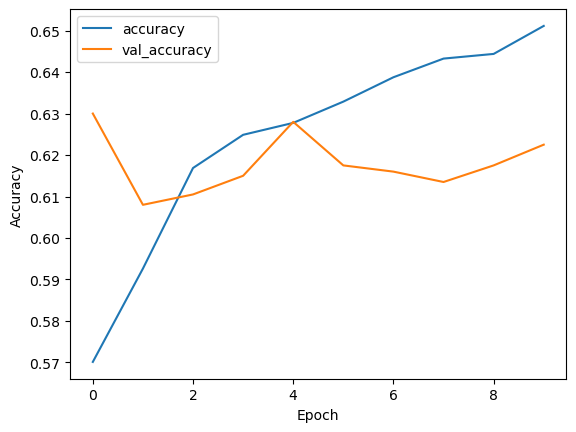

In [21]:
model = keras.Sequential([
    layers.Input(shape=(96, 96, 3)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model
history = model.fit(train_dataset, validation_data=val_dataset, epochs=10)

# Plot the training history
def plot_history(history):
    plt.plot(history.history['accuracy'], label='accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_history(history)

It seems that the accuracy of the validation set is quite low, around 63%. But the accuracy for the training set is also low (65%). This indicates that basic Nueral Network is struggling to find patterns in image data. These results are consistent with the theory. It is not enough to learn the relationships between single pixels in an image, for finding complex patterns. That's why convolution approach works much better for image data.

For the next model I will replace the first layer with a convolutional layer. I will also add max-pooling after it, to reduce the number of outputs while preseving important features. All other parameters will stay the same:

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 16s 61ms/step - accuracy: 0.5405 - loss: 0.7408 - val_accuracy: 0.7140 - val_loss: 0.6301
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.6964 - loss: 0.6181 - val_accuracy: 0.7680 - val_loss: 0.6131
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 16s 63ms/step - accuracy: 0.7380 - loss: 0.5952 - val_accuracy: 0.7715 - val_loss: 0.6001
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.7584 - loss: 0.5811 - val_accuracy: 0.7775 - val_loss: 0.5913
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.7662 - loss: 0.5716 - val_accuracy: 0.7735 - val_loss: 0.5831
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.7754 - loss: 0.5634 - val_accuracy: 0.7770 - val_loss: 0.5785
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.7791 - loss: 0.5564 - val_accuracy: 0.7775 - val_loss: 0.5749
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - accuracy: 0.7855 - loss: 0.5499 - 

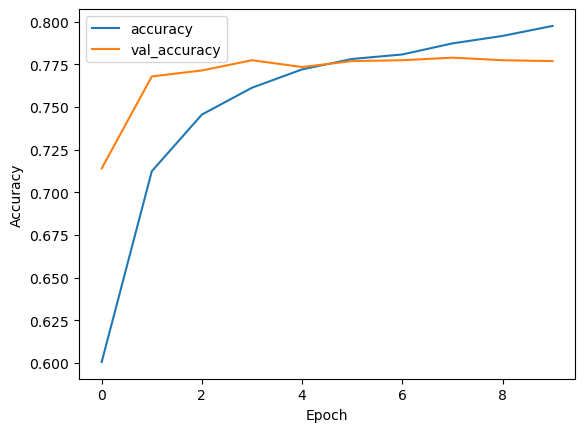

In [22]:
model = keras.Sequential([
    layers.Input(shape=(96, 96, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model
history = model.fit(train_dataset, validation_data=val_dataset, epochs=10)

# Plot the training history
plot_history(history)

The above results show that after adding a convolutional layer, the accuracy jumped to 78%. Next, I will try a model with two convolutional layers:

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 81ms/step - accuracy: 0.6172 - loss: 0.6415 - val_accuracy: 0.7165 - val_loss: 0.5393
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - accuracy: 0.7705 - loss: 0.5031 - val_accuracy: 0.7325 - val_loss: 0.5257
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.7763 - loss: 0.4868 - val_accuracy: 0.7355 - val_loss: 0.5203
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.7828 - loss: 0.4767 - val_accuracy: 0.7380 - val_loss: 0.5186
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 84ms/step - accuracy: 0.7890 - loss: 0.4684 - val_accuracy: 0.7405 - val_loss: 0.5189
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.7940 - loss: 0.4592 - val_accuracy: 0.7420 - val_loss: 0.5190
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.8024 - loss: 0.4499 - val_accuracy: 0.7395 - val_loss: 0.5211
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 82ms/step - accuracy: 0.8074 - loss: 0.4404 - 

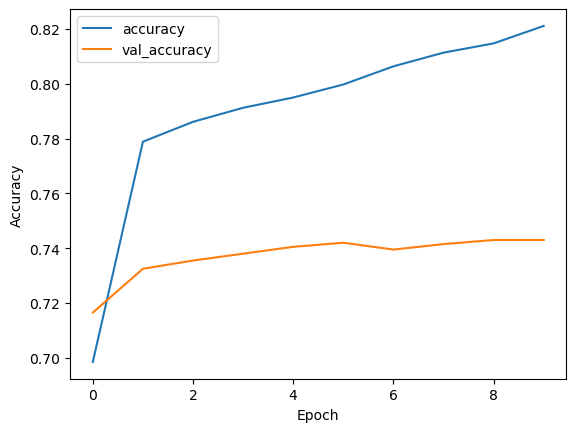

In [23]:
model = keras.Sequential([
    layers.Input(shape=(96, 96, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model
history = model.fit(train_dataset, validation_data=val_dataset, epochs=10)

# Plot the training history
plot_history(history)

After adding another convolutional layer the accuracy dropped to 74%. There is also a significant overfitting, as the training set accuracy reached 81%. I will do the hyperparameter tuning and comparison in the next section.

# 4. Results and Analysis

The results of the previous section gave me a good indication of model capabilities. Unfortunately, I cannot run a model on a bigger set, because of the resources limitation, but I can apply regularization and other tuning techniques to improve the model.

First, I will address the overfitting. The learning on a train set does not generalize well and performs much worse on a validation set. One of the ways to solve that is to add a dropout layer. This will disable some weights on each training iteration, and force the weights to be less interdependent:

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 85ms/step - accuracy: 0.5616 - loss: 0.6997 - val_accuracy: 0.7640 - val_loss: 0.5544
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 84ms/step - accuracy: 0.7364 - loss: 0.5706 - val_accuracy: 0.7680 - val_loss: 0.5039
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 87ms/step - accuracy: 0.7572 - loss: 0.5318 - val_accuracy: 0.7720 - val_loss: 0.4861
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 87ms/step - accuracy: 0.7705 - loss: 0.5163 - val_accuracy: 0.7745 - val_loss: 0.4799
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 89ms/step - accuracy: 0.7675 - loss: 0.5047 - val_accuracy: 0.7755 - val_loss: 0.4775
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 88ms/step - accuracy: 0.7750 - loss: 0.4990 - val_accuracy: 0.7785 - val_loss: 0.4709
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 87ms/step - accuracy: 0.7768 - loss: 0.5041 - val_accuracy: 0.7810 - val_loss: 0.4686
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 84ms/step - accuracy: 0.7851 - loss: 0.4897 - 

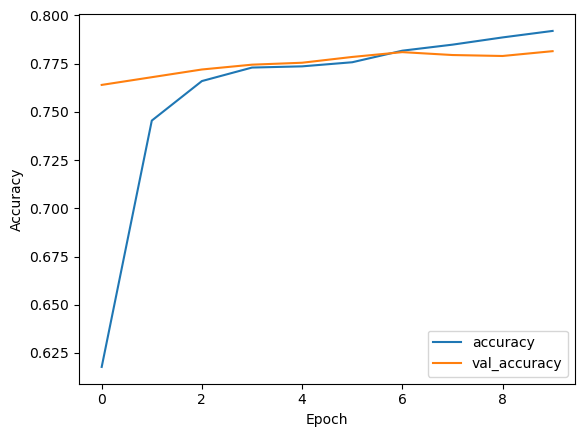

In [36]:
model = keras.Sequential([
    layers.Input(shape=(96, 96, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.8),
    layers.Dense(1, activation='sigmoid')
])

# compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model
history = model.fit(train_dataset, validation_data=val_dataset, epochs=10)

# Plot the training history
plot_history(history)


The dropout layer helped: the accuracy increased to 78%. 

My next optimization is to add batch normalization after each convolution layer. This should stabilize and accelerate the training:

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 40s 155ms/step - accuracy: 0.6187 - loss: 1.0685 - val_accuracy: 0.5185 - val_loss: 2.0586
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 37s 147ms/step - accuracy: 0.7289 - loss: 0.5700 - val_accuracy: 0.7305 - val_loss: 0.5743
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 151ms/step - accuracy: 0.7486 - loss: 0.5340 - val_accuracy: 0.7710 - val_loss: 0.4776
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 39s 154ms/step - accuracy: 0.7548 - loss: 0.5213 - val_accuracy: 0.7915 - val_loss: 0.4687
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 39s 154ms/step - accuracy: 0.7586 - loss: 0.5183 - val_accuracy: 0.7950 - val_loss: 0.4557
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 154ms/step - accuracy: 0.7741 - loss: 0.4997 - val_accuracy: 0.8010 - val_loss: 0.4469
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 146ms/step - accuracy: 0.7788 - loss: 0.4859 - val_accuracy: 0.7975 - val_loss: 0.4364
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 145ms/step - accuracy: 0.7933 - loss: 0

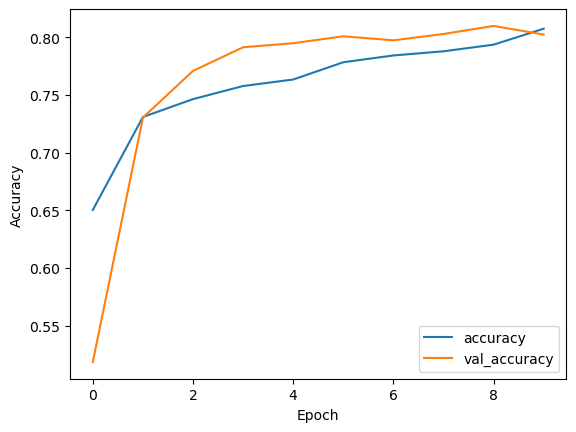

In [33]:
model = keras.Sequential([
    layers.Input(shape=(96, 96, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.8),
    layers.Dense(1, activation='sigmoid')
])

# compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model
history = model.fit(train_dataset, validation_data=val_dataset, epochs=10)

# Plot the training history
def plot_history(history):
    plt.plot(history.history['accuracy'], label='accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_history(history)

The accuracy raised to 81%.

Next, I'd like to add another convolutional layer:

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 44s 172ms/step - accuracy: 0.6429 - loss: 0.8957 - val_accuracy: 0.5100 - val_loss: 5.1448
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 46s 182ms/step - accuracy: 0.7341 - loss: 0.5794 - val_accuracy: 0.6345 - val_loss: 1.1354
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 44s 175ms/step - accuracy: 0.7575 - loss: 0.5245 - val_accuracy: 0.7925 - val_loss: 0.4547
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 43s 173ms/step - accuracy: 0.7688 - loss: 0.5027 - val_accuracy: 0.8010 - val_loss: 0.4334
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 43s 171ms/step - accuracy: 0.7731 - loss: 0.4951 - val_accuracy: 0.7915 - val_loss: 0.4748
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 43s 170ms/step - accuracy: 0.7869 - loss: 0.4604 - val_accuracy: 0.8205 - val_loss: 0.4378
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 44s 175ms/step - accuracy: 0.7953 - loss: 0.4445 - val_accuracy: 0.8245 - val_loss: 0.4146
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 44s 177ms/step - accuracy: 0.8067 - loss: 0

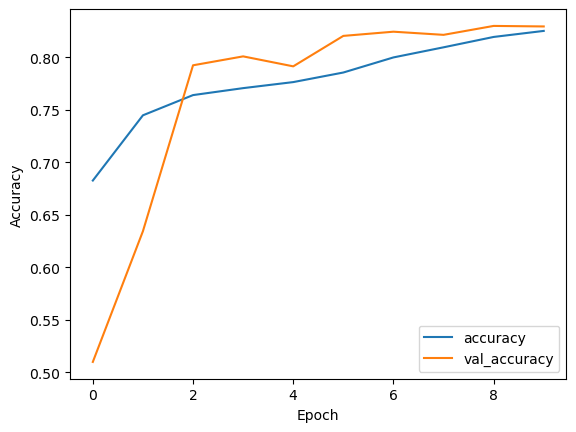

In [37]:
model = keras.Sequential([
    layers.Input(shape=(96, 96, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.8),
    layers.Dense(1, activation='sigmoid')
])

# compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model
history = model.fit(train_dataset, validation_data=val_dataset, epochs=10)

plot_history(history)

The accuracy reached 83%.

#### Parameter tuning
There are several hyperparameters which I had to tune for the models. For example dropout value, learning rate, max-pooling window, number of fitlers and others. Given the resources constraints I've made these tunings manually, with a simple approach: trying several values for a parameter while keeping other parameters constant, and choosing the best. I will discuss it in nore details in Conclusions section. 

Below is a code for creating a subbmission for Kaggle competition, using the test data:

In [48]:
submission = pd.DataFrame()

image_paths = [file for file in os.listdir('test/')]
# Create a list of image filenames
image_paths = ["test/" + id for id in image_paths]
# Create a submission dataframe
submission['id'] = [file.split('.')[0] for file in os.listdir('test/')]

# Create dummy labels for the test dataset
dummy_labels = np.zeros(len(image_paths), dtype=np.int64)

test_dataset = tf.data.Dataset.from_tensor_slices((image_paths, dummy_labels))
# Apply the preprocessing to the test dataset
test_dataset = test_dataset.map(preprocess_image_tf, num_parallel_calls=tf.data.AUTOTUNE)

# Batch and prefetch
test_dataset = test_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

# Make predictions
predictions = model.predict(test_dataset)
# Convert predictions to binary labels
predictions = (predictions > 0.5).astype(np.int64)
predictions = (predictions > 0.5).astype(int)
# Add predictions to the submission dataframe
submission['label'] = predictions
# Save the submission file
submission.to_csv('submission.csv', index=False)

1796/1796 ━━━━━━━━━━━━━━━━━━━━ 351s 195ms/step


Finally, to complete the comparison between models, I will add a pre-trained model (transfer learning). I will use the ResNet, which was trained on ImageNet dataset:

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 61s 234ms/step - accuracy: 0.5257 - loss: 0.6908 - val_accuracy: 0.5555 - val_loss: 0.6812
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 58s 233ms/step - accuracy: 0.5895 - loss: 0.6810 - val_accuracy: 0.5980 - val_loss: 0.6710
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 57s 230ms/step - accuracy: 0.6172 - loss: 0.6730 - val_accuracy: 0.5975 - val_loss: 0.6625
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 58s 231ms/step - accuracy: 0.6361 - loss: 0.6659 - val_accuracy: 0.6160 - val_loss: 0.6549
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 57s 227ms/step - accuracy: 0.6487 - loss: 0.6594 - val_accuracy: 0.6370 - val_loss: 0.6481
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 57s 228ms/step - accuracy: 0.6552 - loss: 0.6532 - val_accuracy: 0.6500 - val_loss: 0.6418
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 57s 230ms/step - accuracy: 0.6635 - loss: 0.6474 - val_accuracy: 0.6645 - val_loss: 0.6361
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 58s 232ms/step - accuracy: 0.6677 - loss: 0

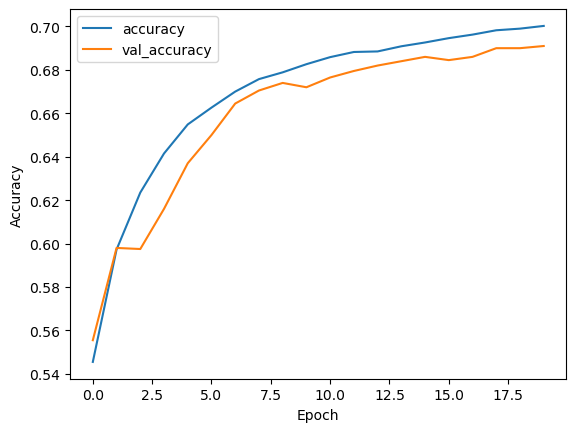

In [47]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(96, 96, 3))

for layer in base_model.layers:
    layer.trainable = False

model = keras.Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model
history = model.fit(train_dataset, validation_data=val_dataset, epochs=20)

# Plot the training history
plot_history(history)

It looks like ResNet model didn't perform too well, reacing only 69% accuracy.

#### Model performance comparision
In the table below I summarized the performance of all models I tried for this project:

| Model | Accuracy | Training time per epoch |
|-------|----------|-------------------------|
|No conv|63%|5 sec|
|1 conv layer|78%|15 sec|
|2 conv layers|74%|21 sec|
|2 conv + dropout|78%|42 sec|
|2 conv + dropout + batch normalization|81%|36 sec|
|3 conv + dropout + batch normalization|83%|45 sec|
|ResNet50|69%|62 sec|

The advantage of CNNs over regular Neural Networks is obvious. After adding a single convolutional layer, the accuracy jumped from 63% to 78%. However adding a second convolutional layer did not help at first. The reason was overfitting. Adding a dropout layer helped to solve that, and I could add additional improvements, like batch normalization and 3rd layer. Tuning the dropout value was essential each time I made changes.

#### Why pre-trained model didn't work
The pre-trained model, ResNet50, didn't achieve a good accuracy. I believe the main reason is the big difference in image types. ResNet was trained on ImageNet data, which contains images from a daily life, like animals, plants, tools and and other objects, while the data for this project contained medical scans of tissues and cells on a microscopic level, which have very different patterns. So a simple convolutional network performed much better than a complex ResNet model.

# 5. Conclusion
In conclusion, I can say that this project gave me a basic practical understanding of implementing CNNs using the keras library. I saw the power behind convolutional networks for image recognition, and I learned the various optimization techniques and effectiveness of hyperparameter tuning.

The main challenge while working with CNNs is the limitation of compute power. Training a model on 10000 samples can take over 10 minutes. This makes optimization/tuning process quite tedious, and therefore I mostly used manual tuning (trial and error approach). Training on the whole training set of 220,000 images is impossible on simple CPU. This highlights the breakthrough in Deep Learning field in 2012, when researchers found a way to run models on multiple GPUs in parallel (AlexNet). It is indeed very handy. Unfortunately, my attempts to use GPU on Google colab didn't work, as I couldn't copy the 6 GB of images from Kaggle (Kaggle API didn't help).

As for future improvements for this project, first of all I would solve the compute limitations and train the model on the whole training set of 220,000 images. I already had an attempt to run it on a 20000 set, and the accuracy jumped to 87%. Running on the whole set will probably bring it to over 95%. Another improvement is to add more layers, which make much sense with large data. And finally, I would try various data augmentation techniques, not only on the train set, but also on the test set (test-time augmentation technique).